Practical Implementation

To effectively compare different dimensionality reduction techniques, we can create a synthetic dataset with a clear structure: a spiral “roulade” shape in 3D space, and then observe how different methods project it into 2D.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS, TSNE

# Roulade point generator functions
def uniform_spiral(density=3, steps=100):
    x, y = [], []
    for i in range(steps):
        x.append((i/steps)**0.5*math.cos((i/steps)**0.5*density*np.pi*2))
        y.append((i/steps)**0.5*math.sin((i/steps)**0.5*density*np.pi*2))
    return x, y

def uniform_roll(xli, yli, width=7, angle=0.25, density=5, noise_factor=0.05):
    nx, ny, nz, d = [], [], [], []
    d1 = [((x**2+y**2)**0.5) for x,y in zip(xli, yli)]
    for i in range(density):
        nx.extend([(width+x)*math.cos(angle*i/density*np.pi*2) + (random.random()-0.5)*noise_factor for x in xli])
        ny.extend([(width+x)*math.sin(angle*i/density*np.pi*2) + (random.random()-0.5)*noise_factor for x in xli])
        nz.extend(yli)
        d.extend(d1)
    return nx, ny, nz, d

def roll_generator(to_array=True, spiral_density=3, spiral_steps=20, width=7, angle=0.3, density=5):
    x, y = uniform_spiral(density=spiral_density, steps=spiral_steps)
    x, y, z, d = uniform_roll(x, y, width=width, angle=angle, density=density)

    if to_array:
        return np.array([x, y, z]).T, d
    else:
        return x, y, z, d


Visualizing the 3D Roulade
We can visualize our synthetic 3D data structure to better understand what we’re working with:

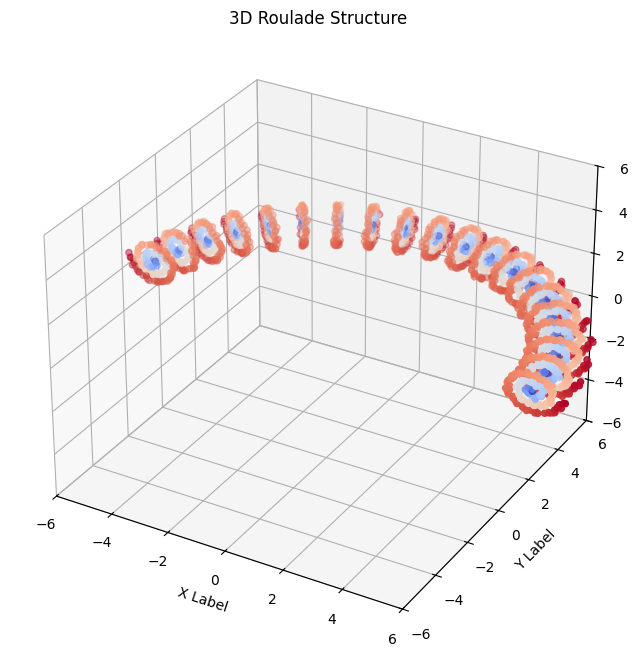

In [2]:
def plot_roulade(x, y, z, d=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    plt.title('3D Roulade Structure')
    plt.show()

# Generate and visualize the roulade
xl, yl = uniform_spiral()
x, y, z, d = uniform_roll(xl, yl, width=7, angle=0.5, density=20, noise_factor=0.15)
plot_roulade(x, y, z, d=d)

1. PCA Projection

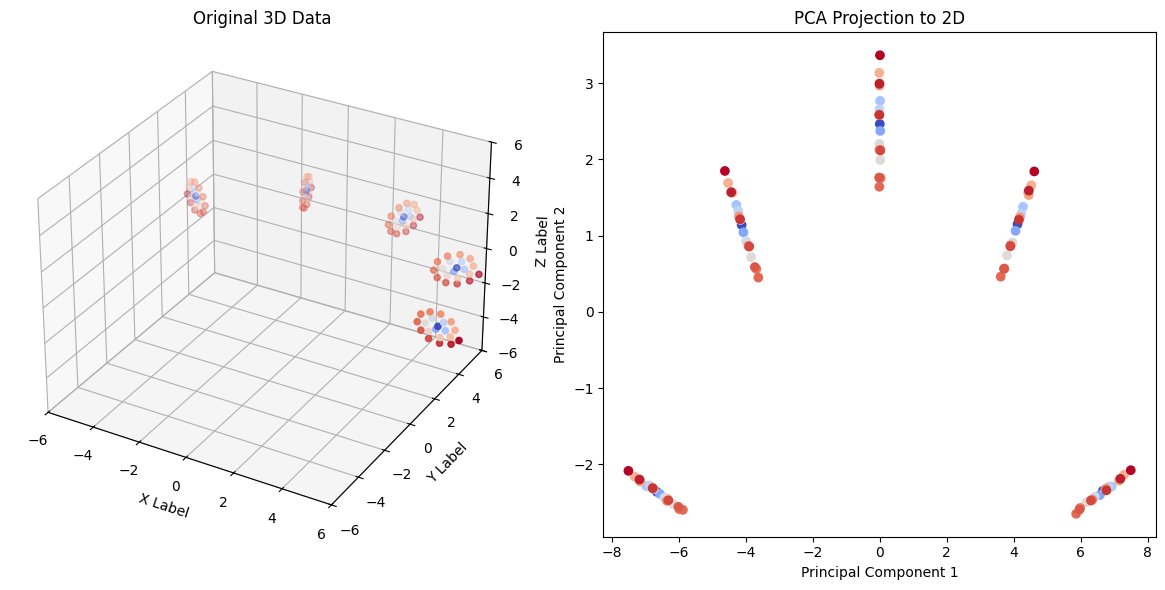

In [3]:
def show_PCA(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    # Plot original 3D data
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # PCA transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    embedding = PCA(n_components=2)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    ax2.set_title('PCA Projection to 2D')

    plt.tight_layout()
    plt.show()

show_PCA()

2. Kernel PCA Projection

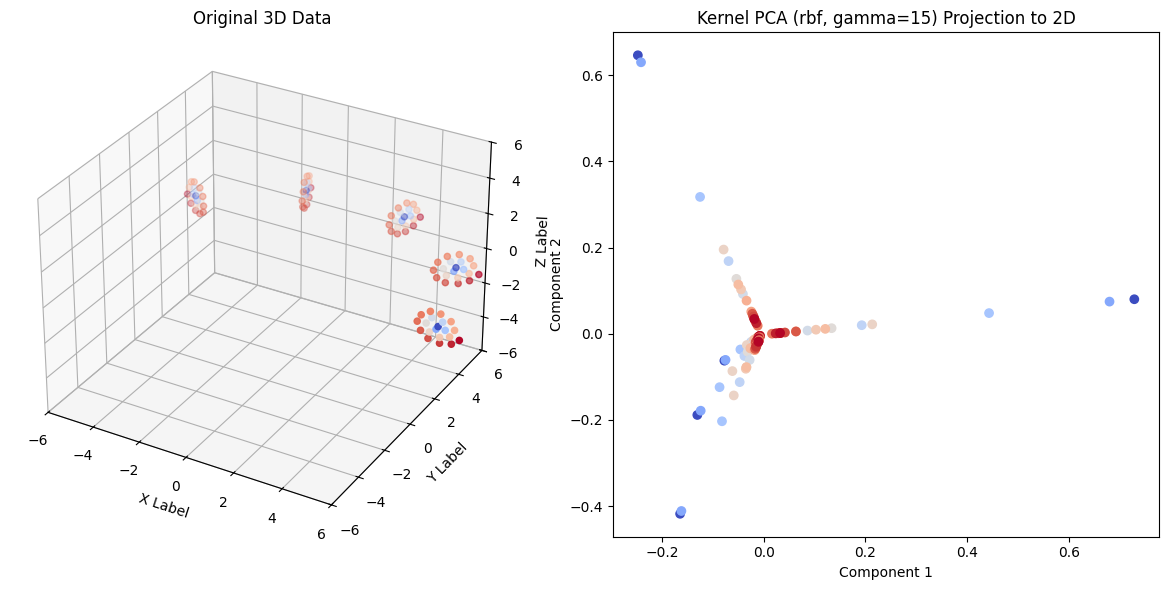

In [4]:
def show_KernelPCA(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5, kernel='rbf', gamma=15):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    # Plot original 3D data
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # Kernel PCA transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    embedding = KernelPCA(n_components=2, kernel=kernel, gamma=gamma)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title(f'Kernel PCA ({kernel}, gamma={gamma}) Projection to 2D')

    plt.tight_layout()
    plt.show()

show_KernelPCA()

3. MDS Projection

C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


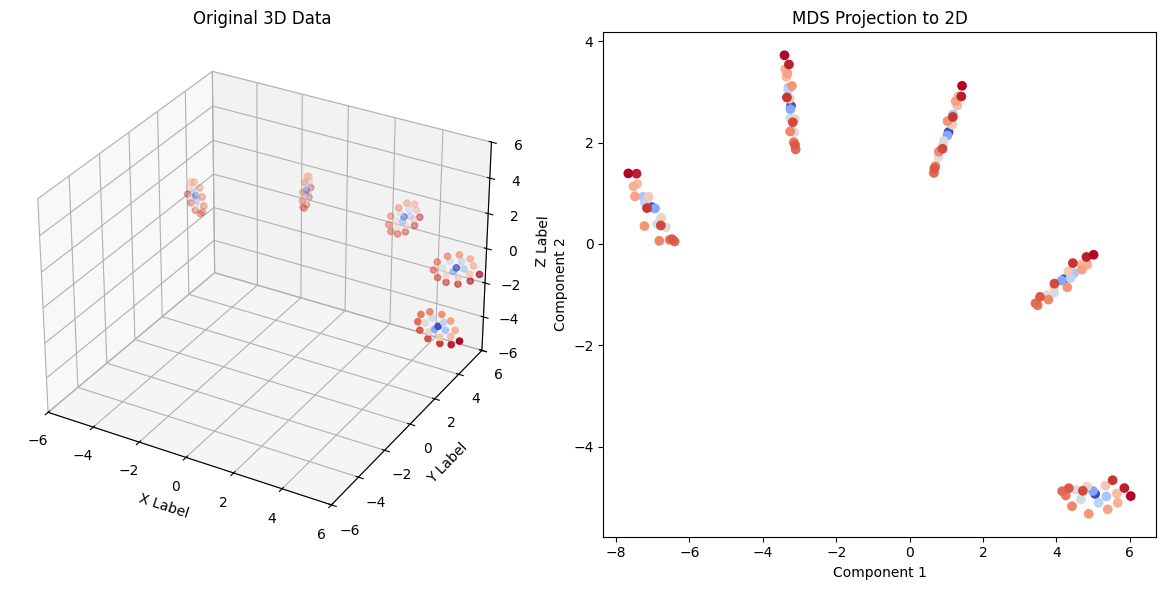

In [5]:
def show_MDS(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    # Plot original 3D data
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # MDS transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    embedding = MDS(n_components=2)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title('MDS Projection to 2D')

    plt.tight_layout()
    plt.show()

show_MDS()

4. t-SNE Projection

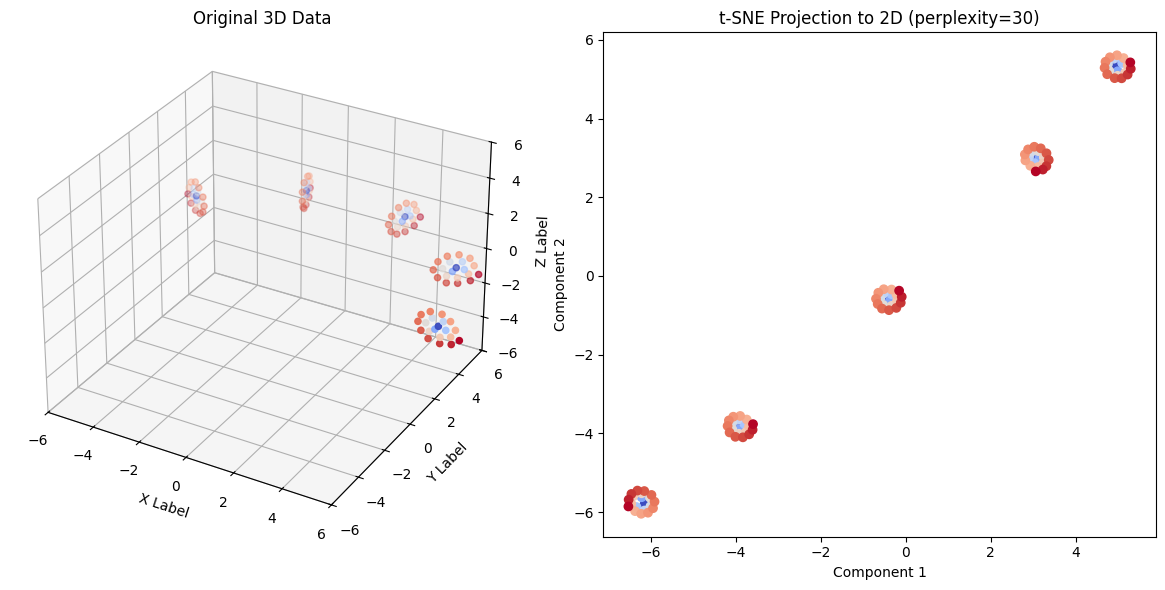

In [6]:
def show_tSNE(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5,
              metric='euclidean', perplexity=30):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    # Plot original 3D data
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # t-SNE transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                           spiral_steps=spiral_steps, width=width,
                           angle=angle, density=roll_density)

    embedding = TSNE(n_components=2, metric=metric, perplexity=perplexity)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title(f't-SNE Projection to 2D (perplexity={perplexity})')

    plt.tight_layout()
    plt.show()

show_tSNE()

UMAP (Uniform Manifold Approximation and Projection)
UMAP is a more recent technique that addresses some limitations of t-SNE:

It maintains the global structure of the data more effectively
It offers faster computation and better scalability
It can be used for general non-linear dimension reduction tasks

C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


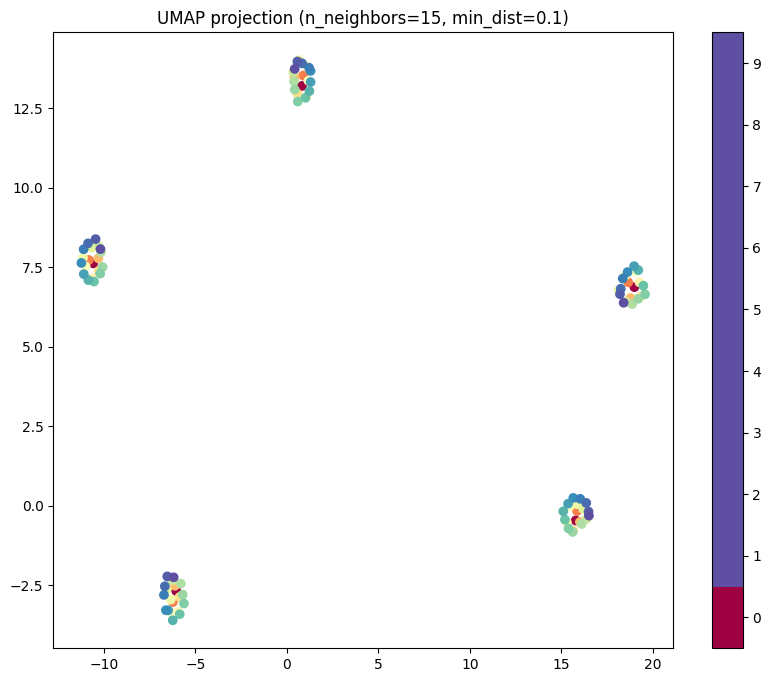

In [7]:
import umap


def show_UMAP(data, labels, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    embedding = reducer.fit_transform(data)

    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(f'UMAP projection (n_neighbors={n_neighbors}, min_dist={min_dist})')
    plt.show()

points, d = roll_generator(to_array=True, 
                           spiral_density=3, 
                           spiral_steps=20, 
                           width=7, 
                           angle=0.5, 
                           density=5)

show_UMAP(data=points, labels=d, n_neighbors=15, min_dist=0.1)

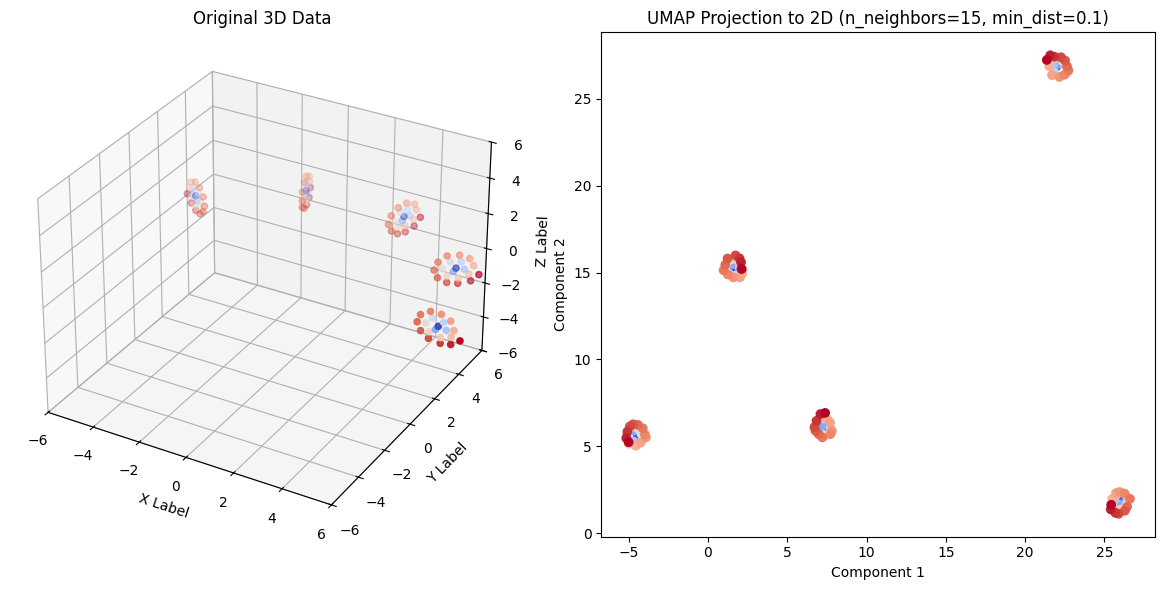

In [8]:
import umap
import matplotlib.pyplot as plt

def show_UMAP_side_by_side(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5,
                           n_neighbors=15, min_dist=0.1):
    fig = plt.figure(figsize=(12, 6))
    
    # 1. Wygenerowanie danych dla wykresu 3D
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                                spiral_steps=spiral_steps, width=width,
                                angle=angle, density=roll_density)

    # 2. Wykres oryginalnych danych 3D (lewa strona)
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # 3. Wygenerowanie danych jako tablicy dla modelu UMAP
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                               spiral_steps=spiral_steps, width=width,
                               angle=angle, density=roll_density)

    # 4. Transformacja UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    points_transformed = reducer.fit_transform(points)
    points_transformed_t = points_transformed.T # Transpozycja, tak jak w tSNE

    # 5. Wykres po transformacji UMAP (prawa strona)
    ax2 = fig.add_subplot(122)
    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title(f'UMAP Projection to 2D (n_neighbors={n_neighbors}, min_dist={min_dist})')

    plt.tight_layout()
    plt.show()

# Wywołanie funkcji
show_UMAP_side_by_side()

TriMAP
TriMAP extends the idea of preserving global and local structures of high-dimensional data by focusing on triplet relationships among data points:

It keeps an anchor data point closer to a positive point than to a negative point
It often maintains both local and global structures better than t-SNE and UMAP in certain cases

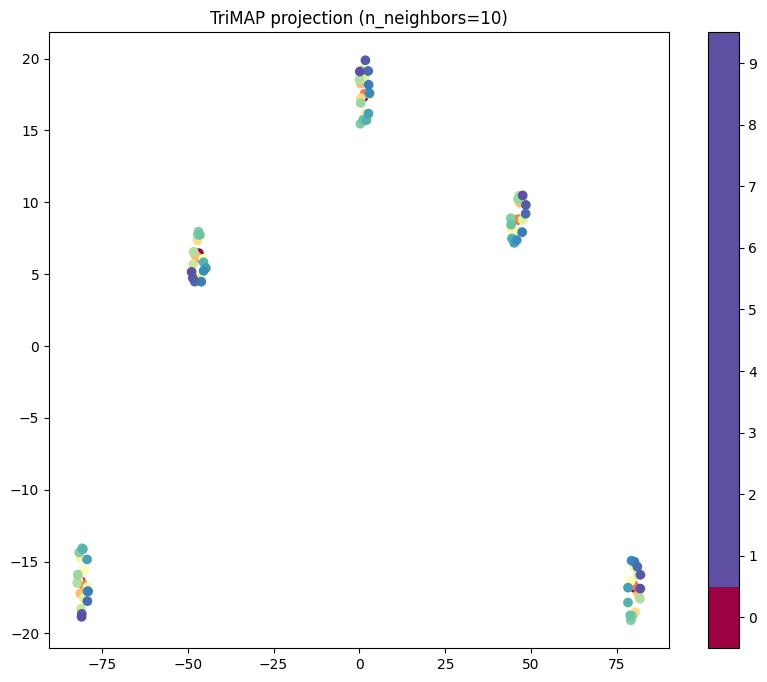

In [9]:
import trimap

def show_TriMAP(data, labels, n_neighbors=10):
    embedding = trimap.TRIMAP(n_inliers=n_neighbors).fit_transform(data)

    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(f'TriMAP projection (n_neighbors={n_neighbors})')
    plt.show()


show_TriMAP(data=points, labels=d, n_neighbors=10)

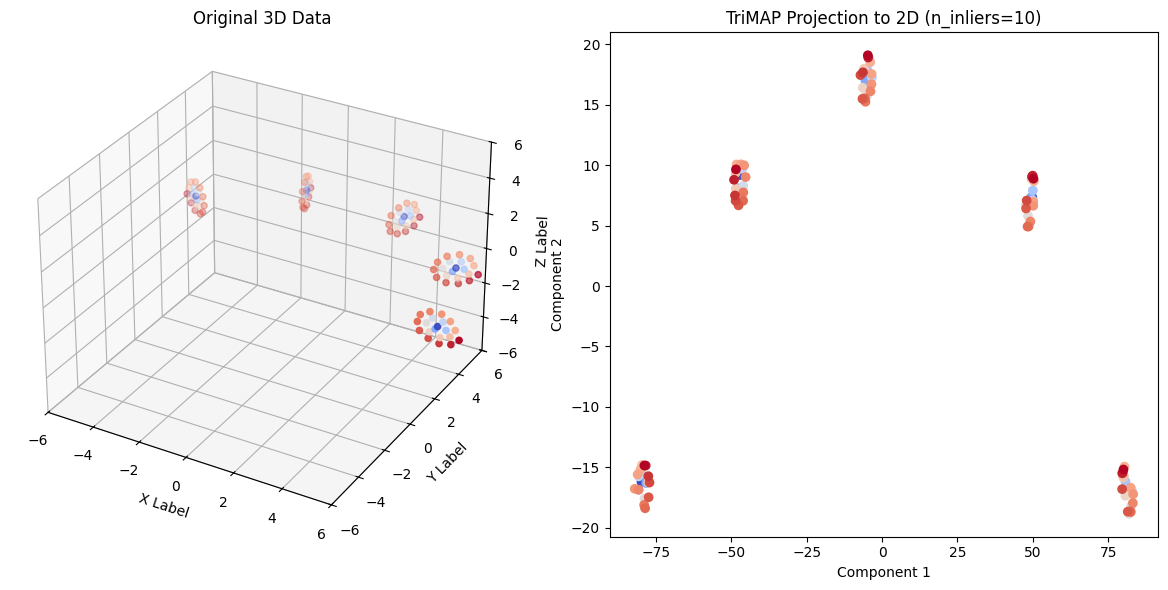

In [10]:
import trimap
import matplotlib.pyplot as plt

def show_TriMAP_side_by_side(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5,
                             n_neighbors=10):
    fig = plt.figure(figsize=(12, 6))
    
    # 1. Wygenerowanie danych dla wykresu 3D
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                                spiral_steps=spiral_steps, width=width,
                                angle=angle, density=roll_density)

    # 2. Wykres oryginalnych danych 3D (lewa strona)
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # 3. Wygenerowanie danych jako tablicy dla modelu TriMAP
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                               spiral_steps=spiral_steps, width=width,
                               angle=angle, density=roll_density)

    # 4. Transformacja TriMAP
    reducer = trimap.TRIMAP(n_inliers=n_neighbors)
    points_transformed = reducer.fit_transform(points)
    points_transformed_t = points_transformed.T # Transpozycja do wykresu

    # 5. Wykres po transformacji TriMAP (prawa strona)
    ax2 = fig.add_subplot(122)
    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title(f'TriMAP Projection to 2D (n_inliers={n_neighbors})')

    plt.tight_layout()
    plt.show()

# Wywołanie funkcji
show_TriMAP_side_by_side()

PaCMAP (Pairwise Controlled Manifold Approximation and Projection)
PaCMAP is designed to address limitations of t-SNE and UMAP with less computational overhead:

It explicitly balances the preservation of local and global data relationships
It provides an efficient and scalable approach to visualizing high-dimensional data

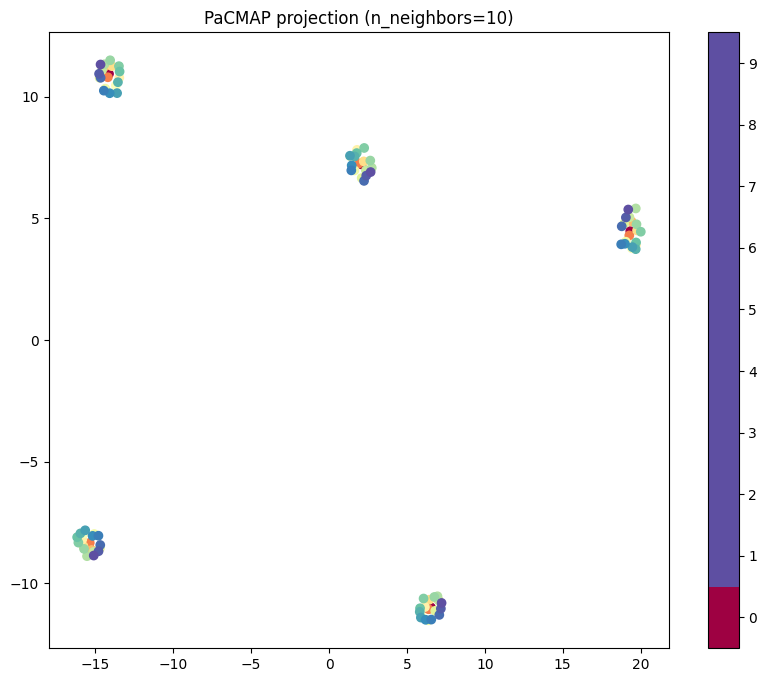

In [11]:
import pacmap

def show_PaCMAP(data, labels, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0):
    embedding = pacmap.PaCMAP(n_neighbors=n_neighbors,
                             MN_ratio=MN_ratio,
                             FP_ratio=FP_ratio).fit_transform(data)

    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(f'PaCMAP projection (n_neighbors={n_neighbors})')
    plt.show()


show_PaCMAP(data=points, labels=d, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0)

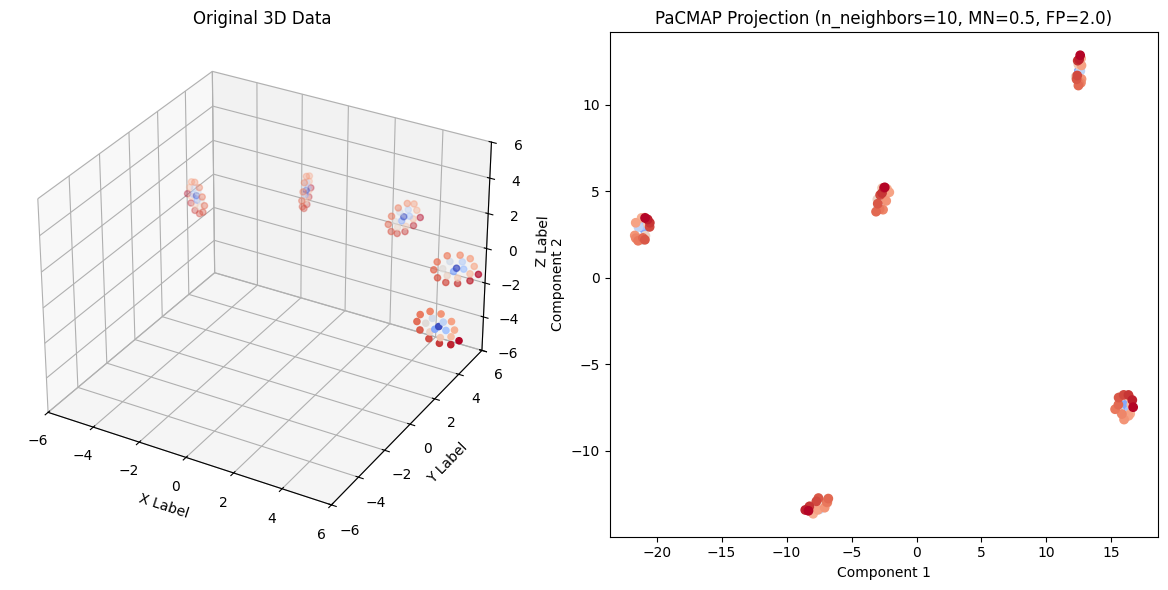

In [12]:
import pacmap
import matplotlib.pyplot as plt

def show_PaCMAP_side_by_side(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5,
                             n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0):
    fig = plt.figure(figsize=(12, 6))
    
    # 1. Wygenerowanie danych dla wykresu 3D
    x, y, z, d = roll_generator(to_array=False, spiral_density=spiral_density,
                                spiral_steps=spiral_steps, width=width,
                                angle=angle, density=roll_density)

    # 2. Wykres oryginalnych danych 3D (lewa strona)
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title('Original 3D Data')

    # 3. Wygenerowanie danych jako tablicy dla modelu PaCMAP
    points, d = roll_generator(to_array=True, spiral_density=spiral_density,
                               spiral_steps=spiral_steps, width=width,
                               angle=angle, density=roll_density)

    # 4. Transformacja PaCMAP
    reducer = pacmap.PaCMAP(n_neighbors=n_neighbors, MN_ratio=MN_ratio, FP_ratio=FP_ratio)
    points_transformed = reducer.fit_transform(points)
    points_transformed_t = points_transformed.T # Transpozycja do wykresu

    # 5. Wykres po transformacji PaCMAP (prawa strona)
    ax2 = fig.add_subplot(122)
    ax2.scatter(points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm)
    ax2.set_xlabel('Component 1')
    ax2.set_ylabel('Component 2')
    ax2.set_title(f'PaCMAP Projection (n_neighbors={n_neighbors}, MN={MN_ratio}, FP={FP_ratio})')

    plt.tight_layout()
    plt.show()

# Wywołanie funkcji
show_PaCMAP_side_by_side()